<a href="https://colab.research.google.com/github/otaviau/PCVK_Genap_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 - Operasi Citra Sederhana

**NIM**: 244107020053  
**Nama**: Otavia Ulandari <br>
**Kelas**: 3B <br>
**Prodi**: D-IV Teknik Informatika  
**Jurusan**: Teknologi Informasi

## Setup awal
Import library dan mount Google Drive.

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
import glob

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#agar tidak menulis path berulang-ulang
BASE_PATH = '/content/drive/MyDrive/PCVK/Gambar'

def baca_bgr(nama_file):
    return cv.imread(f'{BASE_PATH}/{nama_file}')

def tampilkan(img_list, judul_list, cmap=None):
    #fungsi bantu untuk menampilkan beberapa gambar sekaligus (before-after dst)
    n = len(img_list)
    plt.figure(figsize=(5*n, 5))
    for i, (img, judul) in enumerate(zip(img_list, judul_list)):
        plt.subplot(1, n, i+1)
        if img.ndim == 3:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap='gray')
        plt.title(judul)
    plt.show()


## D1.3 - Transformasi Linier Brightness
`g(x,y) = f(x,y) + b`

 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan nilai kecerahan: 80


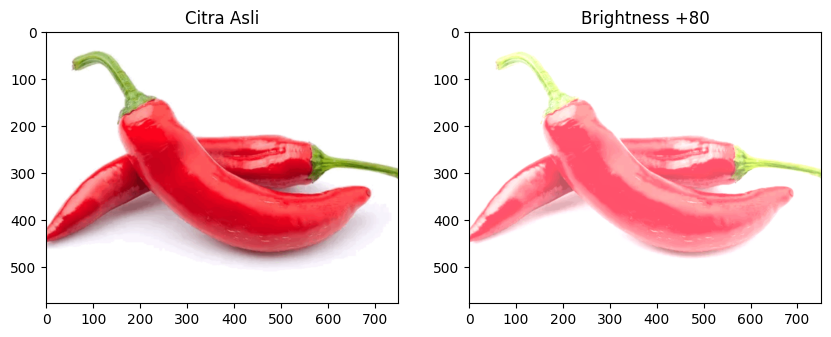

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 0

original = baca_bgr('cabai.png')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2 ]):
            brightness_image[y, x, c] = np.clip(int(original[y, x, c]) + brightness, 0, 255)

tampilkan([original, brightness_image], ['Citra Asli', f'Brightness {brightness:+d}'])


#**TUGAS PRAKTIKUM**

## Tugas 1 - Inverse Citra
`g(x,y) = 255 - f(x,y)` Karena hanya pengurangan dari 255, hasilnya otomatis selalu di rentang 0-255, jadi tidak perlu truncate.

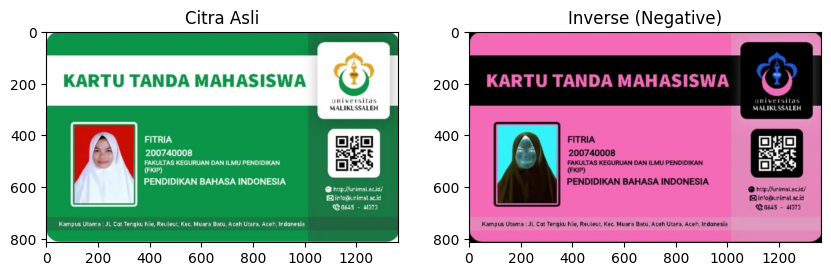

In [ ]:
original = baca_bgr('contohktm.png')

inverse_image = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

#cara cepat tanpa for-loop (hasilnya sama persis):
#inverse_image = 255 - original

tampilkan([original, inverse_image], ['Citra Asli', 'Inverse (Negative)'])


## Tugas 2 - Transformasi Contrast
Rumus Contrast Correction Factor:

`F = 259*(C+255) / (255*(259-C))`

`R' = F*(R-128) + 128` (berlaku sama untuk G dan B), lalu di-truncate ke 0-255.

 Mengubah kontras dan tingkat kecerahan citra 
-----------------------------------------------
Masukkan tingkat kecerahan : 50
Masukkan kontras : 50


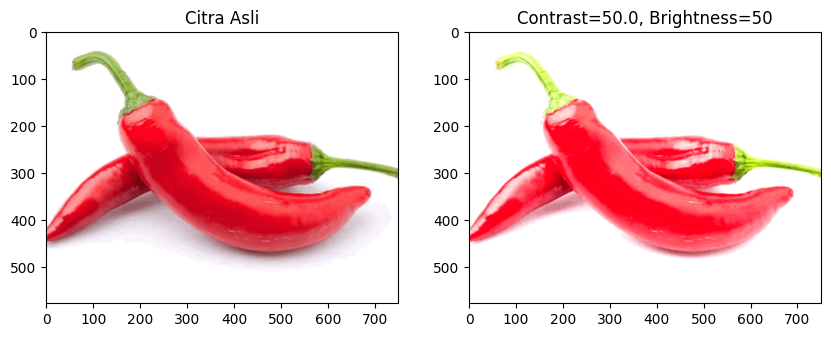

In [ ]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('-----------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')
    brightness, contrast = 0, 0

original = baca_bgr('cabai.png')

factor = (259 * (contrast + 255)) / (255 * (259 - contrast))
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai = factor * (int(original[y, x, c]) - 128) + 128 + brightness
            contrast_image[y, x, c] = np.clip(nilai, 0, 255)

tampilkan([original, contrast_image], ['Citra Asli', f'Contrast={contrast}, Brightness={brightness}'])


## Tugas 3 - Transformasi Logarithmic Brightness
`s = c * log(1 + r)`
Supaya hasil `s` tetap berada di rentang 0-255, konstanta `c` dihitung otomatis berdasarkan nilai pixel maksimum, lalu dikalikan dengan slider kecerahan yang diinput user.

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
------------------------------------------------------------
Masukkan nilai kecerahan: 60


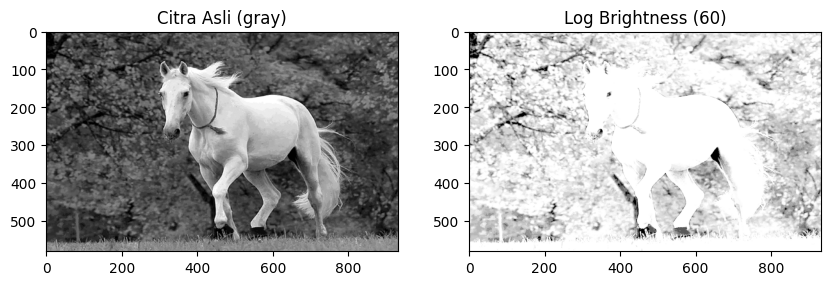

In [ ]:
print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('------------------------------------------------------------')
try:
    kecerahan = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    kecerahan = 50

original = baca_bgr('kuda.png')
original_gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

#c dihitung supaya nilai maksimum tetap <= 255
c = 255 / math.log(1 + 255)

log_image = np.zeros(original_gray.shape, original_gray.dtype)
for y in range(original_gray.shape[0]):
    for x in range(original_gray.shape[1]):
        r = int(original_gray[y, x])
        s = c * math.log(1 + r) * (kecerahan / 50)
        log_image[y, x] = np.clip(s, 0, 255)

tampilkan([original_gray, log_image], ['Citra Asli (gray)', f'Log Brightness ({kecerahan})'])


## Tugas 4 - Grayscale (Averaging, Lightness, Luminance)
3 rumus grayscale pada modul:

- `Avg = (R+G+B)/3`
- `Lightness = (max(R,G,B) + min(R,G,B)) / 2`
- `Luminance = 0.21R + 0.72G + 0.07B`

OpenCV membaca gambar dengan urutan channel BGR, bukan RGB.

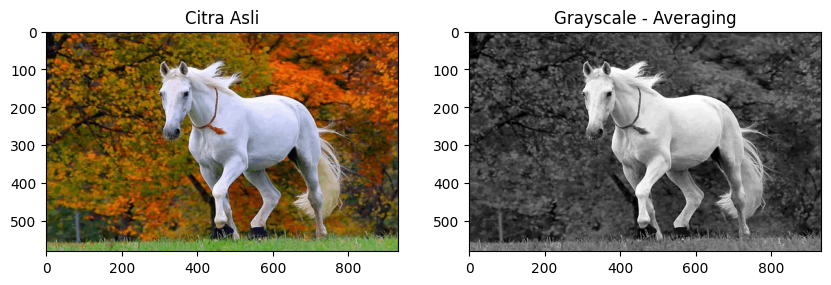

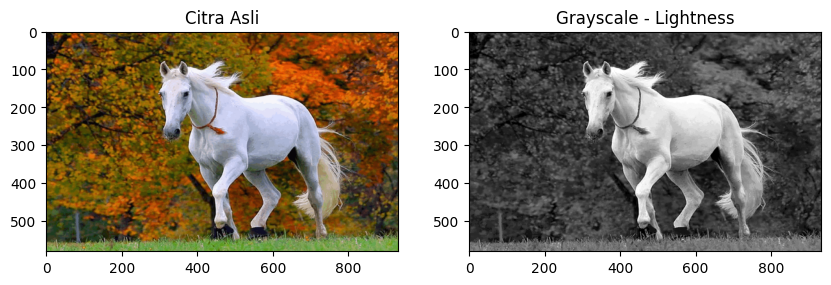

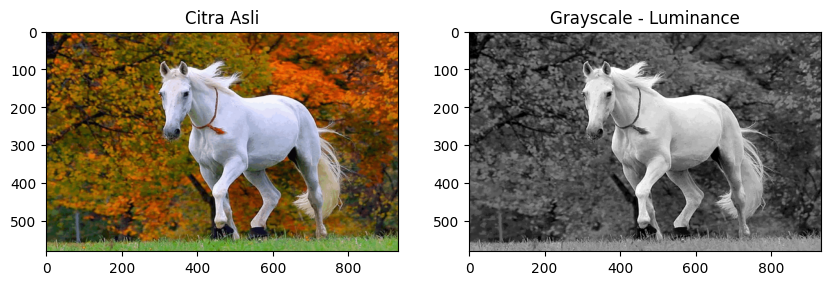

In [ ]:
original = baca_bgr('kuda.png')
h, w, _ = original.shape

avg_img = np.zeros((h, w), np.uint8)
light_img = np.zeros((h, w), np.uint8)
lum_img = np.zeros((h, w), np.uint8)

for y in range(h):
    for x in range(w):
        b, g, r = original[y, x]  #urutan BGR di OpenCV
        b, g, r = int(b), int(g), int(r)

        avg_img[y, x] = (r + g + b) / 3
        light_img[y, x] = (max(r, g, b) + min(r, g, b)) / 2
        lum_img[y, x] = 0.21*r + 0.72*g + 0.07*b

tampilkan([original, avg_img], ['Citra Asli', 'Grayscale - Averaging'])
tampilkan([original, light_img], ['Citra Asli', 'Grayscale - Lightness'])
tampilkan([original, lum_img], ['Citra Asli', 'Grayscale - Luminance'])


## Tugas 5 - Tampilkan Warna Tertentu, Sisanya Grayscale
Saya memilih warna merah tetap berwarna dan bagian lain menjadi grayscale.

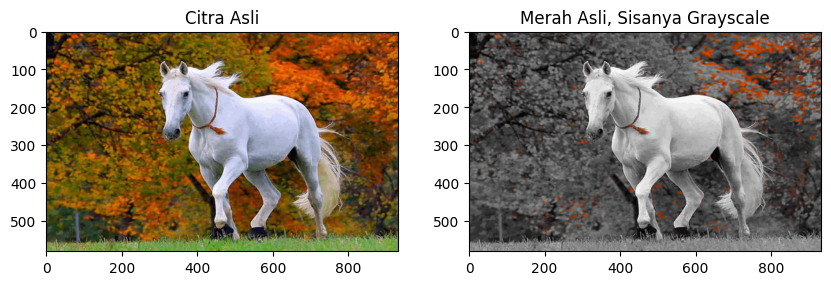

In [ ]:
original = baca_bgr('kuda.png')
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

#rentang warna merah di HSV (merah ada di 2 ujung Hue: dekat 0 dan dekat 180)
mask1 = cv.inRange(hsv, (0, 70, 50), (10, 255, 255))
mask2 = cv.inRange(hsv, (170, 70, 50), (180, 255, 255))
mask_merah = cv.bitwise_or(mask1, mask2)  #255 = area merah, 0 = area lain

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)  #supaya jumlah channel sama dengan original

mask_3ch = cv.cvtColor(mask_merah, cv.COLOR_GRAY2BGR)  #0/255 di 3 channel

#area mask=255 (merah) ambil dari 'original', area mask=0 ambil dari 'gray_3ch'
hasil = np.where(mask_3ch == 255, original, gray_3ch)

tampilkan([original, hasil], ['Citra Asli', 'Merah Asli, Sisanya Grayscale'])


## Tugas 6 - Gamma Correction
Gamma Correction: `I' = 255 * (I/255) ^ (1/gamma)`.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 60


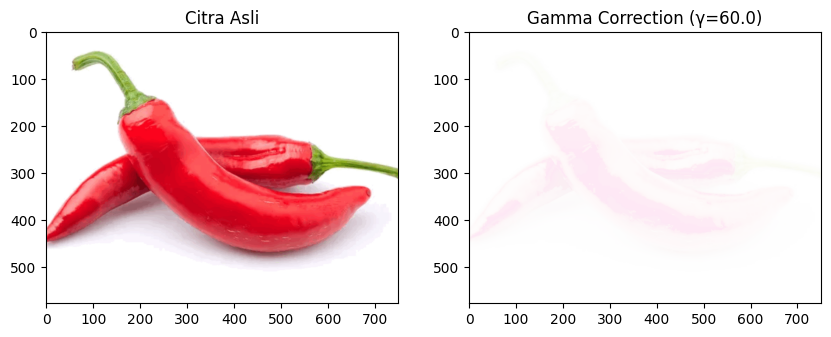

In [ ]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

original = baca_bgr('cabai.png')
gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai = 255 * ((int(original[y, x, c]) / 255) ** (1 / gamma))
            gamma_image[y, x, c] = np.clip(nilai, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); plt.title('Citra Asli')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)); plt.title(f'Gamma Correction (γ={gamma})')
plt.show()


## Tugas 7 - Simulasi Image Depth (Kuantisasi Warna)
`level = 255 / (2^bit_depth - 1)`
`C' = round((C/level)) * level`

 Simulasi Bit Depth 
----------------------
Masukkan bit depth tujuan (1-8): 5
Bit depth awal  : 8 bit
Bit depth tujuan: 5 bit
Jumlah level    : 32


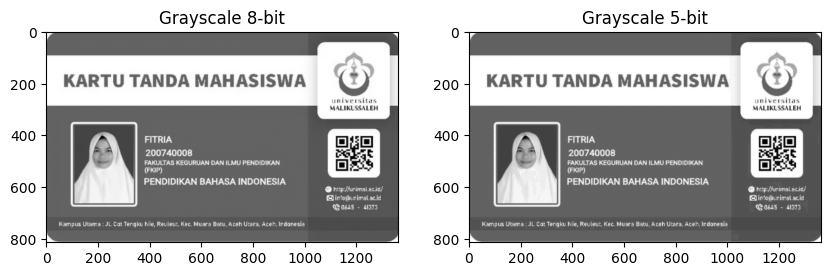

In [ ]:
print(' Simulasi Bit Depth ')
print('----------------------')
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')
    bit_depth = 3

original = cv.imread(f'{BASE_PATH}/contohktm.png', cv.IMREAD_GRAYSCALE)

level = 255 / (pow(2, bit_depth) - 1)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        c = original[y, x]
        depth_image[y, x] = round(c / level) * level

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {pow(2, bit_depth)}')

tampilkan([original, depth_image], ['Grayscale 8-bit', f'Grayscale {bit_depth}-bit'])


## Tugas 8 - Average Denoising + PSNR

In [45]:
#1. baca citra asli
original = baca_bgr('kuda.png')

JALUR_PASTI = '/content/drive/MyDrive/PCVK/Gambar/'

#2. baca semua citra noise
cv_img = []

for img_path in sorted(glob.glob(f'{JALUR_PASTI}/*.png')):
    n = cv.imread(img_path)

    if n is not None:
        #mrnyamakan ukuran dengan citra asli
        n = cv.resize(n, (original.shape[1], original.shape[0]))
        cv_img.append(n)

print(f'Jumlah citra noise ditemukan: {len(cv_img)}')

#Cek ukuran
for i, img in enumerate(cv_img):
    print(f'Gambar {i+1}: {img.shape}')

Jumlah citra noise ditemukan: 5
Gambar 1: (582, 933, 3)
Gambar 2: (582, 933, 3)
Gambar 3: (582, 933, 3)
Gambar 4: (582, 933, 3)
Gambar 5: (582, 933, 3)


In [ ]:
jumlah_list = [10, 20, 40, 80, 100]
hasil_list = []

for jumlah in jumlah_list:

    subset = cv_img[:jumlah]

    stacked = np.stack(subset, axis=0).astype(np.float64)

    rata2 = np.mean(stacked, axis=0)

    rata2 = np.clip(rata2, 0, 255).astype(np.uint8)

    nilai_psnr = PSNR(original, rata2)

    hasil_list.append((jumlah, rata2, nilai_psnr))

    print(f'Average {jumlah:>3} citra -> PSNR = {nilai_psnr:.2f} dB')

Average  10 citra -> PSNR = 9.86 dB
Average  20 citra -> PSNR = 9.86 dB
Average  40 citra -> PSNR = 9.86 dB
Average  80 citra -> PSNR = 9.86 dB
Average 100 citra -> PSNR = 9.86 dB


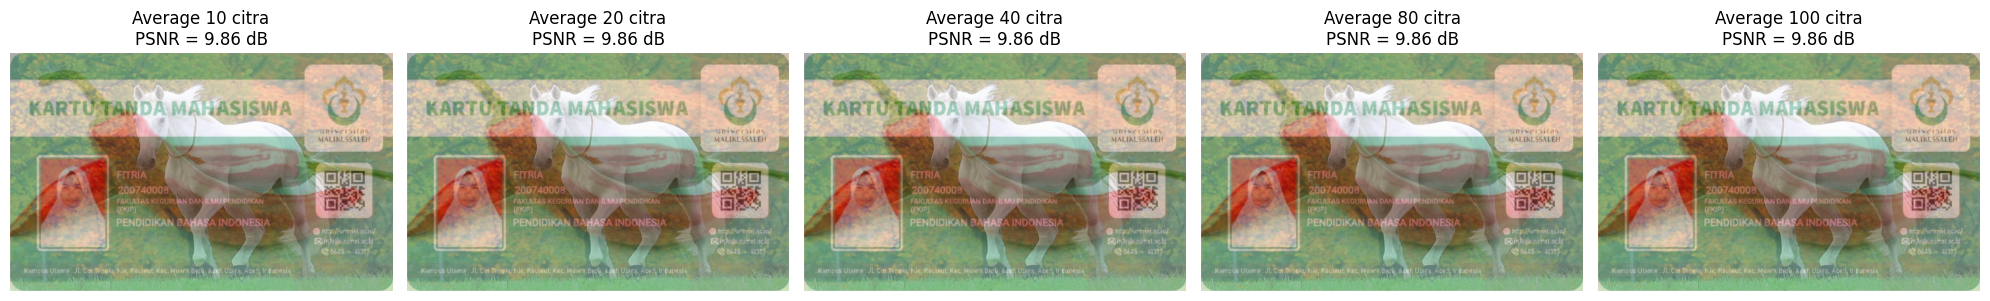

In [ ]:
plt.figure(figsize=(20, 5))

for i, (jumlah, img, psnr_val) in enumerate(hasil_list):

    plt.subplot(1, 5, i + 1)

    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

    plt.title(
        f'Average {jumlah} citra\n'
        f'PSNR = {psnr_val:.2f} dB'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

### Jawaban dari soal nomor 8:

1. Semakin banyak citra umumnya meningkatkan PSNR, tetapi peningkatannya semakin kecil.
2. Sekitar 80–100 citra, peningkatan PSNR mulai tidak terlalu signifikan.
3. Kesimpulan: Average denoising efektif mengurangi Gaussian Noise. Semakin banyak citra yang dirata-ratakan, kualitas citra semakin baik, tetapi setelah jumlah tertentu peningkatannya semakin kecil.

## Tugas 9 - Image Masking (Operator Logika)

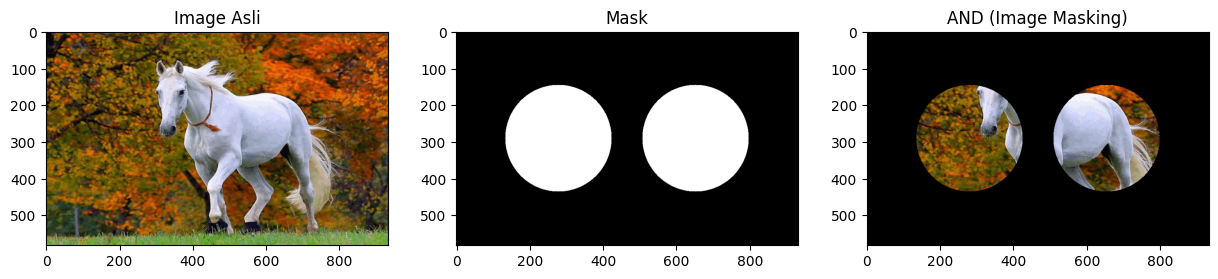

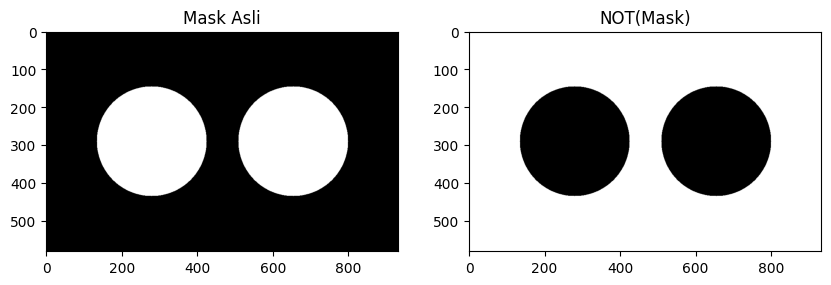

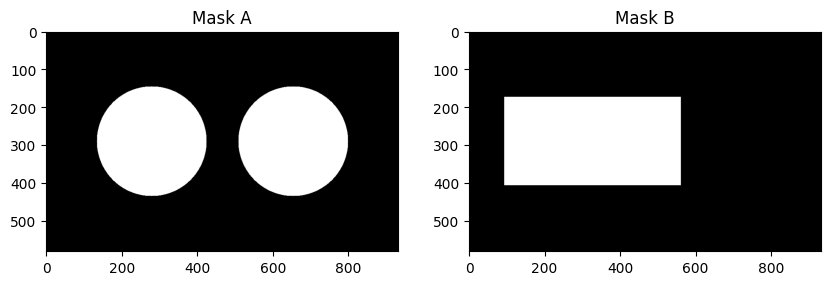

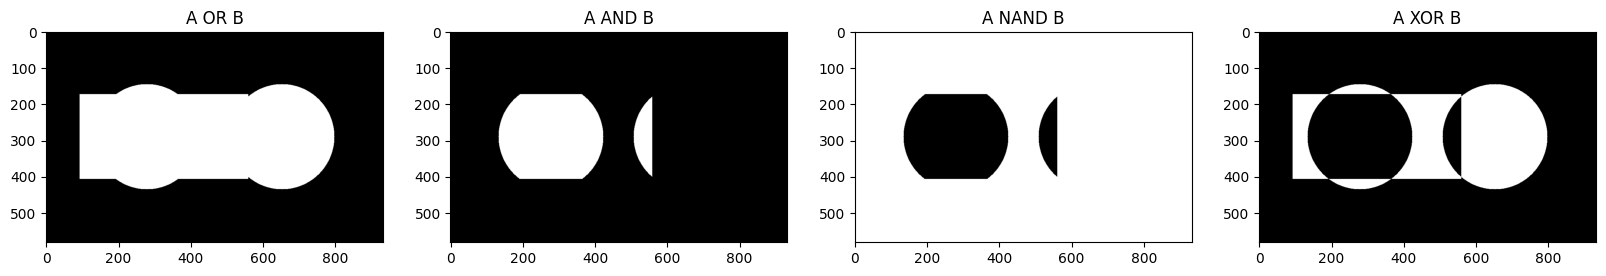

In [ ]:
original = baca_bgr('kuda.png')
h, w = original.shape[:2]

# buat mask: 2 lingkaran putih di atas background hitam
mask = np.zeros((h, w), np.uint8)
cv.circle(mask, (int(w*0.3), int(h*0.5)), int(h*0.25), 255, -1)
cv.circle(mask, (int(w*0.7), int(h*0.5)), int(h*0.25), 255, -1)

# ----- AND (yang biasa dipakai untuk image masking) -----
hasil_and = cv.bitwise_and(original, original, mask=mask)
tampilkan([original, mask, hasil_and], ['Image Asli', 'Mask', 'AND (Image Masking)'])

# ----- NOT (komplemen mask) -----
mask_not = cv.bitwise_not(mask)
tampilkan([mask, mask_not], ['Mask Asli', 'NOT(Mask)'])

# ----- OR -----
# untuk contoh OR/XOR/NAND, kita buat 1 mask kedua (bentuk kotak) supaya perbedaannya terlihat jelas
mask_b = np.zeros((h, w), np.uint8)
cv.rectangle(mask_b, (int(w*0.1), int(h*0.3)), (int(w*0.6), int(h*0.7)), 255, -1)

hasil_or = cv.bitwise_or(mask, mask_b)
hasil_and2 = cv.bitwise_and(mask, mask_b)
hasil_nand = cv.bitwise_not(hasil_and2)
hasil_xor = cv.bitwise_xor(mask, mask_b)

tampilkan([mask, mask_b], ['Mask A', 'Mask B'])
tampilkan([hasil_or, hasil_and2, hasil_nand, hasil_xor],
          ['A OR B', 'A AND B', 'A NAND B', 'A XOR B'])


Analisa singkat:
- **NOT**: membalik warna, area putih jadi hitam dan sebaliknya (komplemen).
- **OR**: hasilnya gabungan (union) semua area putih dari kedua mask.
- **AND**: hasilnya hanya area yang putih di kedua mask sekaligus (irisan/intersection) — ini yang dipakai untuk memotong bagian foto sesuai bentuk mask.
- **NAND**: kebalikan dari AND, jadi semua area **kecuali** irisan tadi.
- **XOR**: hanya area yang putih di salah satu mask saja, tapi tidak di keduanya (area yang tidak overlap).

## Tugas 10 - Perbaikan Foto Malam Hari

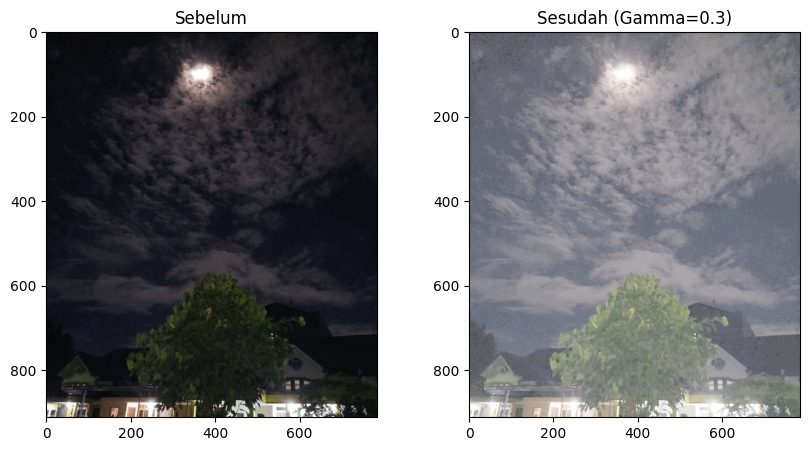

In [ ]:
original = baca_bgr('malam.png')

gamma = 0.3  #nilai 0.3 - 0.7, semakin kecil semakin terang
hasil = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            # nilai = 255 * ((int(original[y, x, c]) / 255) ** (1 / gamma))
            nilai = 255 * ((int(original[y, x, c]) / 255) ** gamma)
            hasil[y, x, c] = np.clip(nilai, 0, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); plt.title('Sebelum')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB)); plt.title(f'Sesudah (Gamma={gamma})')
plt.show()


Alasan pemilihan metode & resiko:
- **Alasan**: Gamma Correction membesarkan nilai pixel gelap secara *tidak linier* (kurva), sehingga detail di bagian gelap ikut terangkat lebih banyak dibanding bagian yang sudah terang. Berbeda dengan Linear Brightness yang menambah nilai secara rata ke semua pixel dan mudah kena truncate di 255.
- **Resiko**: kalau gamma terlalu kecil (misal < 0.3), gambar bisa terlihat 'pucat'/washed out dan noise pada bagian gelap ikut terlihat jelas dan mengganggu.

## Tugas 11 - Perbaikan Kualitas crayfish.jpg

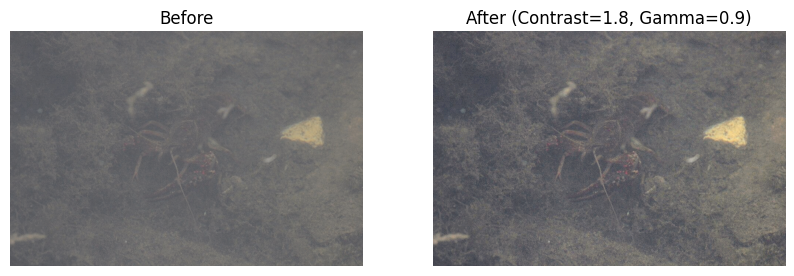

In [46]:
original = baca_bgr('crayfish.png')

#naikkan contrast
contrast = 1.8
brightness = 5

step1 = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            nilai = contrast * (int(original[y, x, c]) - 128) + 128 + brightness

            step1[y, x, c] = np.clip(nilai, 0, 255)


#gamma correction untuk angkat detail gelap
gamma = 0.9

hasil_akhir = np.zeros(original.shape, original.dtype)

for y in range(step1.shape[0]):
    for x in range(step1.shape[1]):
        for c in range(step1.shape[2]):

            nilai = 255 * ((int(step1[y, x, c]) / 255) ** gamma)

            hasil_akhir[y, x, c] = np.clip(nilai, 0, 255)


#tampilkan hasill
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_akhir, cv.COLOR_BGR2RGB))
plt.title(f'After (Contrast={contrast}, Gamma={gamma})')
plt.axis('off')

plt.show()

Jawaban dari soal nomor 11
 - **Metode yang dipilih**: Contrast Transformation + Gamma Correction (2 metode digabung).
- **Alasan pemilihan**: Contrast untuk memperlebar sebaran warna (foto asli terlihat 'flat'/kurang kontras), lalu Gamma Correction untuk mengangkat area gelap tanpa merusak area terang.
- **Parameter terbaik**: contrast = 1.8,
brightness = 5, gamma = 0.9